# 🃏 Analyse statistique de parties de poker Winamax

Mathis KACER, Ivann MINOC

Ce notebook présente une analyse des historiques de parties **Expresso Nitro** et **Expresso** issus de la plateforme Winamax. Ce type de partie a tendance à être rapide. Pour simplifier nos analyses, nous nous sommes limités au jeu avant le flop, qui repose uniquement sur les cartes qu'on a en main.

**Problématique** : Quand faut-il jouer pour gagner au poker ?

Pour les non-initiés au poker, nous vous conseillons de regarder préalablement cette petite vidéo de présentation rapide : 

https://www.youtube.com/watch?v=pSRGErzzIo4 (sous-titres et doublages disponibles en Francais)

**Données** : fichiers d'historiques `.txt` parsés et chargés depuis un stockage S3 (SSPCloud)  
**Objectifs** :
- Décrire les statistiques de jeu globales
- Analyser les comportements selon la position et le stack
- Visualiser les ranges de mains jouées

---

## 0. Configuration

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.creation_bdd_mains import parse_file, parse_folder
from data.creation_bdd_tournois import parse_folder_resume
from data.tri_dossier import trier_fichiers
from data.chargement_txt import load_data_from_s3
from src.ranges import range, affichage_range
from src.decision_par_position import analyse_stack_bb
from src.winrate import winrate_par_position
from src.prediction import feature_engineering
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.formula.api as smf
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from src.comparer_resultats import comparer_bankroll_joueurs

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


SyntaxError: invalid syntax. Perhaps you forgot a comma? (creation_bdd_tournois.py, line 34)

## 1. Chargement des données

Les données brutes sont constituées de fichiers texte (.txt) exportés depuis la plateforme Winamax, collectés à partir des historiques de jeu de plusieurs joueurs — les membres du groupe ainsi que leurs proches.

Chaque fichier correspond à une session de jeu. Ces fichiers suivent un format semi-structuré propre à Winamax, où chaque main est délimitée par un en-tête standardisé et décrit séquentiellement les actions de chaque joueur à chaque rue (préflop, flop, turn, river). Winamax génère également, pour chaque session, un fichier résumé (_summary.txt) qui agrège les informations globales du tournoi : classement final, gains et pertes de chaque participant.

Afin de rendre ces données exploitables, deux parsers Python ont été développés, reposant sur des expressions régulières. Le premier traite les fichiers de mains détaillés et extrait, pour chaque main jouée, les informations pertinentes : identifiants de tournoi, niveau de blindes, position du joueur, cartes distribuées, actions préflop et postflop, résultat financier.

Le joueur d'intérêt (le « héros ») est détecté automatiquement via la ligne Dealt to, ce qui permet au parser de traiter indifféremment les historiques de n'importe quel joueur sans configuration manuelle. Le second parser traite les fichiers résumés et en extrait les résultats globaux de chaque tournoi.
Ces deux parsers produisent chacun un DataFrame pandas consolidé :

tableau_mains — une ligne par main jouée, avec toutes les features comportementales et financières associées (position, stack en BB, fold préflop, all-in préflop, cartes, bénéfice net en BB, etc.)
tableau_tournois — une ligne par tournoi disputé, avec le résultat global (gain ou perte, classement final, buy-in)

Ces deux bases de données constituent le socle sur lequel reposent toutes les analyses statistiques présentées dans ce notebook.

In [2]:
PROJECT_DIR = os.getcwd()

load_data_from_s3(
    project_dir=PROJECT_DIR,
    s3_path='mathiskacer2/diffusion/projet_poker/history.zip'
)

trier_fichiers('data/historique/history/', 'data/mains/', 'data/resumes/')

# prend plusieurs dizaines de secondes

['history', '__MACOSX']


In [45]:
tableau_mains = parse_folder('data/mains/')
tableau_tournois = parse_folder_resume('data/resumes/')

print(f'Mains : {len(tableau_mains):>6} lignes  x {tableau_mains.shape[1]} colonnes')
print(f'Tournois : {len(tableau_tournois):>6} lignes  x {tableau_tournois.shape[1]} colonnes')

# peut prendre plus d'une minute

Mains :  31140 lignes  x 37 colonnes
Tournois :   2728 lignes  x 8 colonnes


## 2. Aperçu du jeu de données

In [4]:
tableau_mains.head(5)

,tournament,buy_in_price,buy_in_rake,buy_in_total,level,hand_id,id_table,numero_main,sequence,sb,bb,datetime,id_tournoi,hero,hero_seat,stack_start,total_players,position,stack_bb,cartes,main,fold_preflop,allin_preflop,flop,turn,river,saw_flop,saw_turn,saw_river,went_to_showdown,won_at_showdown,total_pot,gain,gain bb,benefice net,benefice bb,source_file
0,Expresso,0.230,0.020,0.250,1,3959423895123001345-1-1743180858,3959423895123001345,1,1743180858,10,20,2025-03-28 16:54:18,921875214,MathisKcr,2,500,3,BTN,25.000,3d 6s,63o,True,False,None,None,None,False,False,False,False,False,520,0,0.000,0,0.000,20250328_Expresso(921875214)_real_holdem_no-li...
1,Expresso,0.230,0.020,0.250,1,3959423895123001345-2-1743180865,3959423895123001345,2,1743180865,10,20,2025-03-28 16:54:25,921875214,MathisKcr,2,500,3,BB,25.000,4d 8h,84o,False,False,Ts Qc 5d,None,None,True,False,False,False,False,100,0,0.000,-20,-1.000,20250328_Expresso(921875214)_real_holdem_no-li...
2,Expresso,0.230,0.020,0.250,1,3959423895123001345-3-1743180884,3959423895123001345,3,1743180884,10,20,2025-03-28 16:54:44,921875214,MathisKcr,2,480,3,SB,24.000,Tc 9h,T9o,True,False,None,None,None,False,False,False,False,False,202,0,0.000,-20,-1.000,20250328_Expresso(921875214)_real_holdem_no-li...
3,Expresso,0.230,0.020,0.250,1,3959423895123001345-4-1743180901,3959423895123001345,4,1743180901,10,20,2025-03-28 16:55:01,921875214,MathisKcr,2,460,3,BTN,23.000,Th As,ATo,False,False,None,None,None,False,False,False,False,False,70,70,3.500,30,1.500,20250328_Expresso(921875214)_real_holdem_no-li...
4,Expresso,0.230,0.020,0.250,1,3959423895123001345-5-1743180915,3959423895123001345,5,1743180915,10,20,2025-03-28 16:55:15,921875214,MathisKcr,2,490,3,BB,24.500,9c Th,T9o,True,False,None,None,None,False,False,False,False,False,590,0,0.000,-20,-1.000,20250328_Expresso(921875214)_real_holdem_no-li...


In [5]:
# Types et valeurs manquantes
tableau_mains.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31140 entries, 0 to 31139
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   tournament        31140 non-null  object        
 1   buy_in_price      31140 non-null  float64       
 2   buy_in_rake       31140 non-null  float64       
 3   buy_in_total      31140 non-null  float64       
 4   level             31140 non-null  int64         
 5   hand_id           31140 non-null  object        
 6   id_table          31140 non-null  object        
 7   numero_main       31140 non-null  int64         
 8   sequence          31140 non-null  object        
 9   sb                31140 non-null  int64         
 10  bb                31140 non-null  int64         
 11  datetime          31140 non-null  datetime64[ns]
 12  id_tournoi        31140 non-null  object        
 13  hero              31140 non-null  object        
 14  hero_seat         3114

## 3. Statistiques descriptives globales

Quelques indicateurs clés sur l'ensemble des mains jouées.

In [6]:
stats = {
    'Nombre de mains' : len(tableau_mains),
    'Nombre de joueurs uniques': tableau_mains['hero'].nunique(),
    'Formats de tournoi' : ', '.join(tableau_mains['tournament'].unique()),
    'Fold préflop (%)' : tableau_mains['fold_preflop'].mean() * 100,
    'All-in préflop (%)' : tableau_mains['allin_preflop'].mean() * 100,
    'Vu le flop (%)' : tableau_mains['saw_flop'].mean() * 100,
    'Showdown (%)' : tableau_mains['went_to_showdown'].mean() * 100,
    'Gagné au showdown (%)' : tableau_mains.loc[tableau_mains['went_to_showdown'], 'won_at_showdown'].mean() * 100,
}

for k, v in stats.items():
    if isinstance(v, float):
        print(f'{k:<30} {v:.2f}')
    else:
        print(f'{k:<30} {v}')

Nombre de mains                31140
Nombre de joueurs uniques      3
Formats de tournoi             Expresso, Expresso Freeroll, Expresso Nitro, Expresso Nitro Freeroll, Expresso W.SERIES
Fold préflop (%)               33.38
All-in préflop (%)             20.59
Vu le flop (%)                 54.54
Showdown (%)                   32.60
Gagné au showdown (%)          49.76


## 4. Ranges de mains

Visualisation des ranges pour chaque joueur. Le but ici est de montrer des statistiques pour chaque mains.

Pour cela, on a transformé notre base de données pour harmoniser les mains. \
Statistiquement, on a autant de chance de gagner, avec Roi de trèfle et Dame de coeur qu'avec Roi de carreau et Dame de pique. \
Le seul cas ou les statistique sont plus hautes est lorsque les deux couleurs sont les mêmes (permet de jouer davantage de couleur). On a donc changé les cartes pour indiquer si elles sont "suited" (s) (de la même couleur) ou offsuit (o) (de couleur différentes).\
Pour cela on fait des tables de range, qui indique pour chaque mains existantes des statistiques. \
Nous obtenons donc en haut a droite les cartes de meme couleur et en bas à gauche les cartes de couleur différente.

`metric` peut être :
- `'mean'` — espérance de gain par main
- `'var'`  — volatilité par main
- `'freq'` — fréquence d'ouverture

Ce sont donc les sstatistiques que montrent nos tableaux.

`hero` est le pseudo Winamax du joueur à analyser.

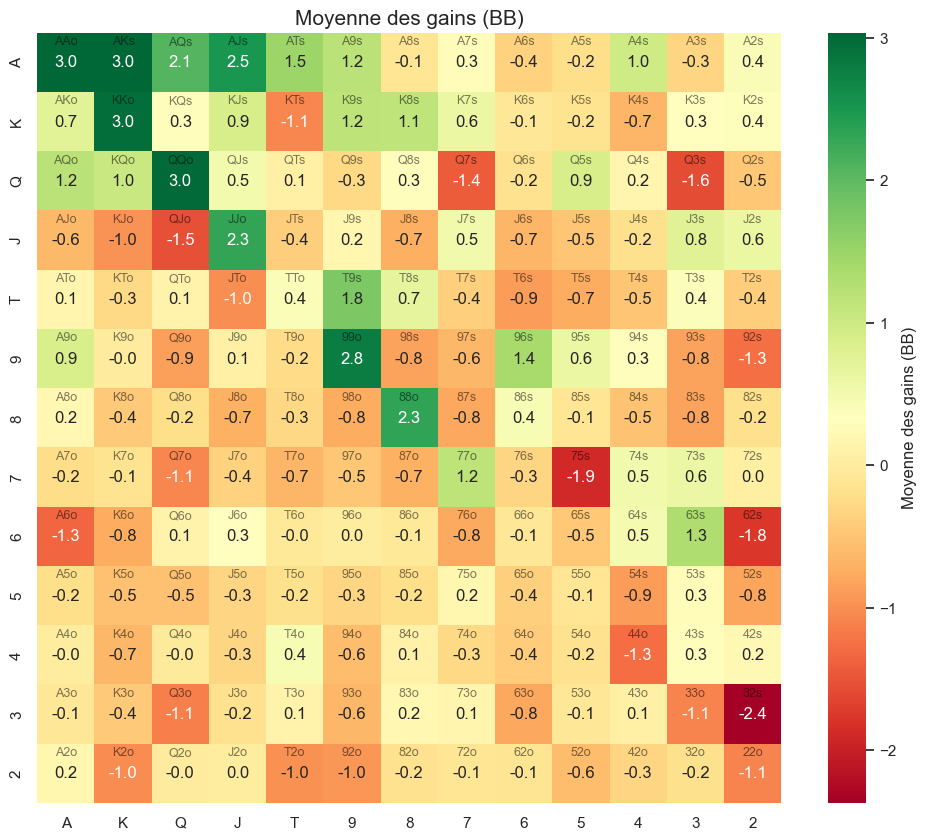

In [13]:
affichage_range(tableau_mains, metric='mean', hero='MathisKcr')

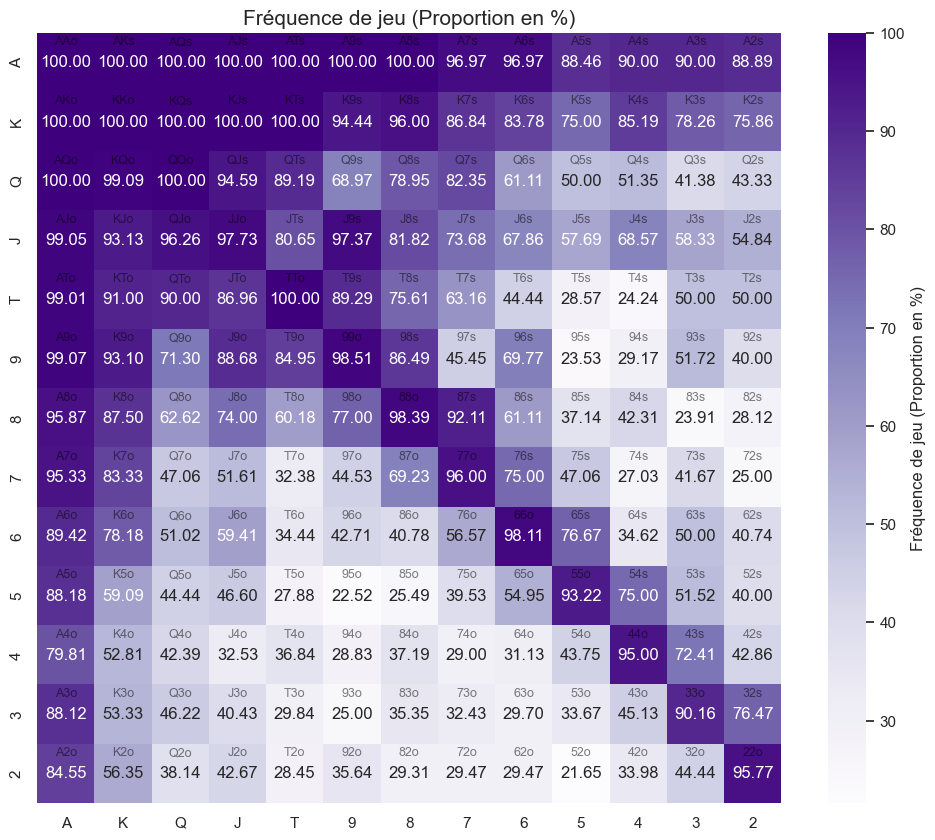

In [14]:
affichage_range(tableau_mains, metric='freq', hero='Samponi')

## 5. Analyse décisionnelle selon le stack

On peut aussi analyser les décisions selon le nombre de jeton que l'on a. On exprime ici le stack en Big Blinde (BB) afin d'harmoniser la décision au cours de la partie et du niveau de blindes. 

On segmente les mains par tranche de **stack en nombre de big blindes** et on observe :
- le taux de **fold préflop** — diminue quand le stack est court (mode push/fold)
- le taux d'**all-in préflop** — augmente très nettement quand le stack est court

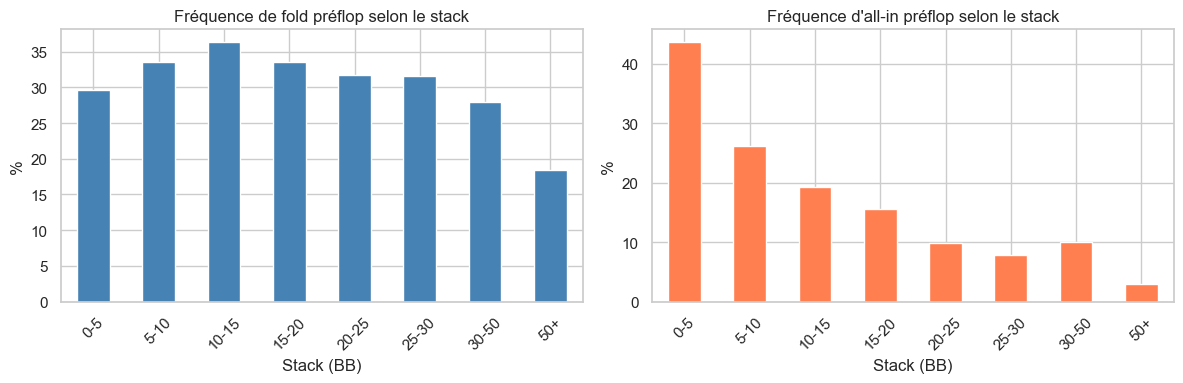

,nb_mains,fold_pf_pct,allin_pf_pct
stack_bb_range,,,
0-5,3193,0.296,0.436
5-10,7008,0.335,0.261
10-15,9762,0.363,0.192
15-20,4560,0.336,0.155
20-25,3621,0.317,0.098
25-30,1529,0.316,0.078
30-50,1293,0.279,0.100
50+,174,0.184,0.029


In [15]:
stats_stack = analyse_stack_bb(tableau_mains)
stats_stack

**Lecture** : En dessous de 10 BB, la fréquence d'all-in préflop dépasse 30 %, reflétant une stratégie all-in/fold adaptée aux types de parties étudiées (Expresso)

## 6. Winrate par position

On peux également essayer de comparer du gain moyen (en BB) selon la position à la table : **BTN**, **SB**, **BB**. Cela permettrait de voir les positions les plus intéressantes à jouer.

En théorie, le BTN (bouton) est la position la plus avantageuse car le joueur agit en dernier postflop.

          nb_mains  winrate_bb  net_bb_total
position                                    
BB           12896      -0.234     -3014.200
BTN          12857      -0.142     -1831.060
SB            5387      -0.241     -1299.550


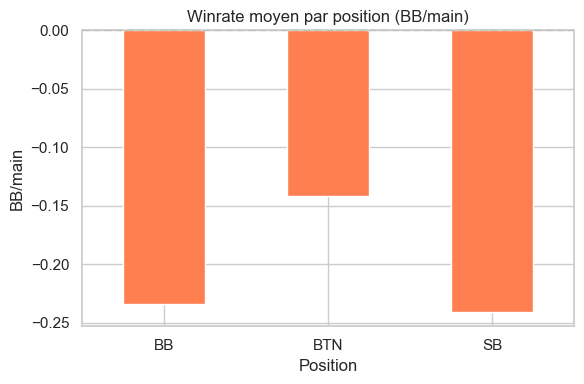

In [16]:
stats_pos = winrate_par_position(tableau_mains)
stats_pos

**Lecture** : Nos données montrent qu'on a tendance perdre dans toutes les positions. Cela est dues aux "blindes" qui peuvent etre déposées par les joueurs sans même jouer. Toutefois, on voit qu'on perd moin lorsqu'on est au bouton (BTN), ce qui suit les théories du poker. Le jeu à cette position est donc plus intéressant.

La comparaison des performances des joueurs : la table "tableau_tournois"

In [ ]:
comparer_bankroll_joueurs(tableau_tournois, ['Samponi', 'MathisKcr'])

## 7. Prédiction de la performance d'une main

Pour répondre à notre problématique — Quand faut-il jouer pour gagner au poker ? — nous avons dépassé l'analyse descriptive pour construire des modèles prédictifs. Nous avons traité deux problèmes distincts :
On essaiera ici de prédire la performance d'une main (le nombre de bb gagnées puis
le fait qu'une main soit perdante ou gagnante) en utilisant :

La Régression : Pour estimer le montant du gain attendu (l'Expected Value) selon les paramètres pré-flop.

La Classification : Pour prédire la probabilité binaire de victoire d'une main donnée."

On segmente crée de nouvelles variables catégorielles :
- la variable **est une paire** — 1 si les cartes sont similaires, 0 sinon
- la variable d'**est meme signe** — 1 si les cartes sont de meme signe, 0 sinon
- la variable **se suivent** — 1 si les cartes sont consécutives, 0 sinon
- la variable **main_gagnante** — 1 si le gain est positif, 0 sinon

Et des nouvelles variables quantitatives :
- la variable **carte haute** — la valeur de la carte la plus forte
- la variable **carte basse** — la valeur de la carte la plus faible

Pre-processing

In [17]:
mains_select = feature_engineering(tableau_mains)

var_numeriques = ['stack_bb', 'level', 'carte haute', 'carte basse']
var_categorielles = ['position', 'est une paire', 'est meme signe', 'se suivent']

mains_select = mains_select[['benefice bb', 'main_gagnante']\
                                    + var_numeriques + var_categorielles + ['main', 'hero']]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), var_numeriques),
    ('cat', OneHotEncoder(handle_unknown='ignore'), var_categorielles)
])

mains_select.head()

,benefice bb,main_gagnante,stack_bb,level,carte haute,carte basse,position,est une paire,est meme signe,se suivent,main,hero
0,0.000,0,25.000,1,6,3,BTN,0,0,0,63o,MathisKcr
1,-1.000,0,25.000,1,8,4,BB,0,0,0,84o,MathisKcr
2,-1.000,0,24.000,1,10,9,SB,0,0,1,T9o,MathisKcr
3,1.500,1,23.000,1,14,10,BTN,0,0,0,ATo,MathisKcr
4,-1.000,0,24.500,1,10,9,BB,0,0,1,T9o,MathisKcr


Régression :


In [25]:
def regression(var_interet, var_auxiliaires, hero):
    reg_pipeline = Pipeline([
        ('prepro', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, max_depth=4))
    ])

    mains_prediction = mains_select[mains_select['hero'] == hero]
    X = mains_prediction[var_auxiliaires]
    y_reg = mains_prediction[var_interet]

    X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

    reg_pipeline.fit(X_train, y_train)
    y_pred_reg = reg_pipeline.predict(X_test)

    print(f"R² Score: {r2_score(y_test, y_pred_reg):.4f}")
    print(f"Erreur Moyenne (MAE): {mean_absolute_error(y_test, y_pred_reg):.2f} BB")

    # pour l'affichage :

    ohe_feature_names = reg_pipeline.named_steps['prepro'].named_transformers_['cat'].get_feature_names_out(var_categorielles)
    all_feature_names = var_numeriques + list(ohe_feature_names)
    arbre_a_afficher = reg_pipeline.named_steps['regressor'].estimators_[0]

    return all_feature_names, arbre_a_afficher

regression('benefice bb', var_numeriques + var_categorielles, 'MathisKcr')


R² Score: 0.0172
Erreur Moyenne (MAE): 2.83 BB


(['stack_bb',
  'level',
  'carte haute',
  'carte basse',
  'position_BB',
  'position_BTN',
  'position_SB',
  'est une paire_0',
  'est une paire_1',
  'est meme signe_0',
  'est meme signe_1',
  'se suivent_0',
  'se suivent_1'],
 DecisionTreeRegressor(max_depth=4, max_features=1.0, random_state=1608637542))

Au départ, on obtenait un R2 négatif, cela est dû à la volatilité très forte et 
l'aléatoire présents dans le poker. \
Nous avons donc décidé de réduire la profondeur maximale (à 4). Ainsi nous obtenons 
un R2 de 0.017. Cela reste très faible. \
Ces résultats soulignent une réalité fondamentale du poker Expresso : la variance. Le résultat d'un coup dépend d'une part de la stratégie pré-flop (signal), mais surtout du tirage aléatoire des cartes communes (bruit).\
 Mathématiquement, le bruit domine le signal sur notre échantillon, limitant la capacité du modèle à prédire un montant précis de gain.
Un arbre associé est affiché ici :

R² Score: 0.0172
Erreur Moyenne (MAE): 2.83 BB


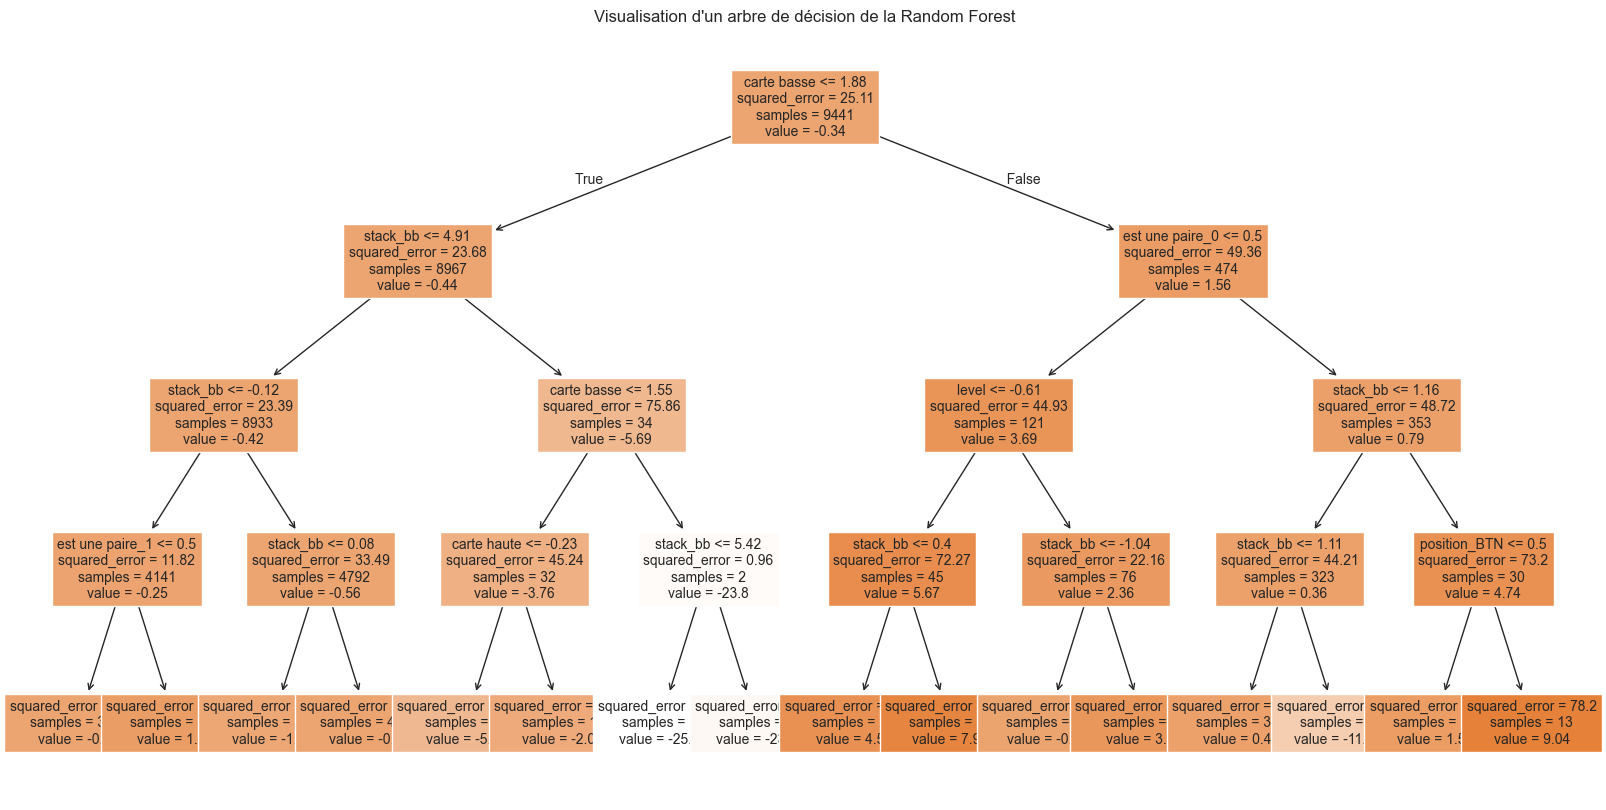

In [28]:
all_feature_names, arbre_a_afficher = regression('benefice bb', var_numeriques + var_categorielles, 'MathisKcr')

plt.figure(figsize=(20, 10))
plot_tree(arbre_a_afficher,
          feature_names=all_feature_names,
          filled=True,
          precision=2,
          fontsize=10,
          max_depth=4)
plt.title("Visualisation d'un arbre de décision de la Random Forest")
plt.show()

La visualisation d'un arbre de décision de notre forêt montre que le modèle segmente logiquement le jeu. \
La première division (le nœud racine) s'effectue sur la hauteur de la carte (high_card).\
 Cela confirme que la force intrinsèque de la main est le premier prédicteur de profit, avant même la position ou la profondeur du tapis (stack).

Régression linéaire

In [44]:
def regression_ols(formule, hero):
    mains_stats = mains_select.rename(columns={'benefice bb': 'benefice_bb',
                                                'stack_bb': 'stack_bb',
                                                'carte haute': 'carte_haute',
                                                'carte basse': 'carte_basse',
                                                'est meme signe': 'est_meme_signe',
                                                'se suivent': 'se_suivent'})

    mains_stats = mains_stats[mains_stats['hero'] == hero]

    # Création du modèle OLS (Ordinary Least Squares)
    model = smf.ols(formula=formule, data=mains_stats)

    # Entraînement (ajustement)
    results = model.fit()

    return results.summary()

formule = "benefice_bb ~ stack_bb + carte_haute + carte_basse + C(est_meme_signe)" \
    "+ C(se_suivent) + level + C(position)"

print(regression_ols(formule, 'MathisKcr'))

                            OLS Regression Results                            
Dep. Variable:            benefice_bb   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     13.45
Date:              mar., 21 avr. 2026   Prob (F-statistic):           1.35e-19
Time:                        23:14:32   Log-Likelihood:                -56956.
No. Observations:               18693   AIC:                         1.139e+05
Df Residuals:                   18684   BIC:                         1.140e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

L'utilisation de statsmodels nous permet de valider la significativité de nos variables. \
Nous observons que les coefficients associés aux positions, à la consécutivité des cartes, leur hauteur et le fait qu'elles soient de même signe sont corrélés au gain avec une p-value inférieure à 0.05, ce qui permet d'affirmer statistiquement de leur importance sur le profit d'une main.

En supprimant les variables non significatives (P>0.5) :

In [30]:
formule = "benefice_bb ~ stack_bb + carte_basse + C(est_meme_signe)" \
"+ C(se_suivent)"

print(regression_ols(formule, 'MathisKcr'))

                            OLS Regression Results                            
Dep. Variable:            benefice_bb   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     26.24
Date:              mar., 21 avr. 2026   Prob (F-statistic):           9.88e-22
Time:                        23:00:39   Log-Likelihood:                -56957.
No. Observations:               18693   AIC:                         1.139e+05
Df Residuals:                   18688   BIC:                         1.140e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

Classification :

In [38]:
def classification(hero):

    mains_prediction = mains_select[mains_select['hero'] == hero]

    X = mains_prediction[var_numeriques + var_categorielles]
    y_class = mains_prediction['main_gagnante']
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

    classif_pipeline = Pipeline([
        ('prepro', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])

    classif_pipeline.fit(X_train_c, y_train_c)
    y_pred_c = classif_pipeline.predict(X_test_c)

    print(classification_report(y_test_c, y_pred_c))
    print(f"AUC Score: {roc_auc_score(y_test_c, classif_pipeline.predict_proba(X_test_c)[:, 1]):.2f}")

    return (y_test_c, y_pred_c)

classification('MathisKcr')

              precision    recall  f1-score   support

           0       0.68      0.68      0.68      2184
           1       0.55      0.55      0.55      1555

    accuracy                           0.63      3739
   macro avg       0.62      0.62      0.62      3739
weighted avg       0.63      0.63      0.63      3739

AUC Score: 0.69


(22751    1
 848      0
 19611    1
 21779    0
 29616    1
         ..
 16057    0
 16082    0
 23360    0
 16258    1
 25702    1
 Name: main_gagnante, Length: 3739, dtype: int64,
 array([0, 0, 0, ..., 1, 0, 0], shape=(3739,)))

Notre classifieur Random Forest affiche une meilleure robustesse que la régression. \
En transformant le gain en une variable binaire (gagné/perdu), nous filtrons une partie de la variance extrême.

La matrice de confusion est donnée :

              precision    recall  f1-score   support

           0       0.68      0.68      0.68      2184
           1       0.55      0.55      0.55      1555

    accuracy                           0.63      3739
   macro avg       0.62      0.62      0.62      3739
weighted avg       0.63      0.63      0.63      3739

AUC Score: 0.69


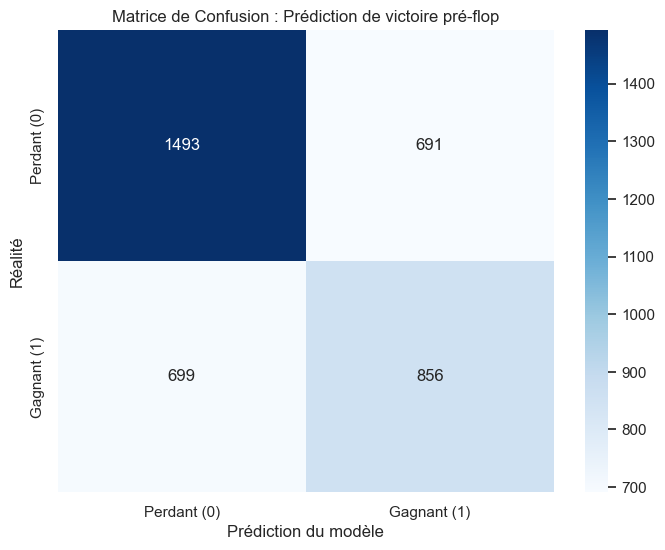

In [42]:
def matrice_confusion(hero):

    y_test_c, y_pred_c = classification(hero)

    cm = confusion_matrix(y_test_c, y_pred_c)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Perdant (0)', 'Gagnant (1)'],
                yticklabels=['Perdant (0)', 'Gagnant (1)'])

    plt.xlabel('Prédiction du modèle')
    plt.ylabel('Réalité')
    plt.title('Matrice de Confusion : Prédiction de victoire pré-flop')
    plt.show()

matrice_confusion('MathisKcr')

L'analyse de la matrice de confusion révèle que le modèle est très performant pour identifier les Vrais Négatifs (les mains perdantes). \
En revanche, il présente une proportion non négligeable de Faux Positifs. Cela signifie que même avec une main statistiquement forte (prédite gagnante), la réalité du jeu (bad beats, confrontations inévitables) conduit souvent à une perte. \
C'est l'illustration statistique de la 'réalisation de l'équité' au poker.

## Conclusion

L’objectif de cette étude était de déchiffrer les mécaniques de gain au sein des tournois Expresso de Winamax en passant d'une analyse descriptive à une approche prédictive. 

Ce projet nous a permis d'explorer l'intégralité du cycle de vie de la donnée : du parsing complexe de fichiers texte bruts à la modélisation par apprentissage statistique. 

Nos analyses confirment que, malgré la rapidité du format "Nitro", le poker reste un jeu de décisions rationnelles : l'importance de la force des mains : 
Comme l'a révélé notre Arbre de Décision, la hauteur des cartes est le premier facteur de segmentation des gains.

De plus, notre modèle Statsmodels a prouvé que la position (notamment le Bouton) offre un avantage statistiquement significatif.
Jouer "en position" n'est pas seulement un conseil de pro, c'est une réalité mathématique mesurable dans les coefficients de nos régressions.

Enfin, l'interaction entre la taille du tapis (stack_bb) et la sélection des mains est cruciale. Le modèle a montré que les stratégies doivent s'adapter à mesure que le tournoi progresse et que les tapis diminuent.

La modélisation a mis en lumière un concept central : le compromis entre signal et bruit.Le $R^2$ relativement faible de nos régressions ne traduit pas une faiblesse du modèle, mais bien la nature intrinsèque du poker. 
Dans un format aussi volatil que l'Expresso, la variance (le hasard des tirages) masque une grande partie du signal stratégique sur le court terme. Cependant, notre Classification a démontré qu'il est possible d'identifier avec une bonne fiabilité les situations à espérance de gain positive.

Pour aller plus loin, on pourrait intégrer le profilage adverse : Ajouter des variables sur le style de jeu des adversaires.
On pourrait aussi analyser le post-flop : étendre l'étude aux décisions prises après le dévoilement des premières cartes communes.

Finalement, ce projet montre parfaitement comment la Data Science permet de rationaliser un environnement incertain, transformant une intuition de joueur en une stratégie validée par les données.